# Statistiques descriptives - Base GDELT GKG (2015 → aujourd'hui)

Ce notebook explore la base Parquet hebdomadaire produite par `gdelt_weekly_pipeline.py`.

**Rappel du schéma de chaque fichier `gdelt_YYYY-MM.parquet` :**

| Colonne | Description |
|---|---|
| `GKGRECORDID` | identifiant unique de l'enregistrement GKG |
| `DATE` | horodatage GDELT au format `YYYYMMDDHHMMSS` |
| `SourceCollectionIdentifier` | canal de collecte GDELT (1=WEB, 2=CITATIONONLY - d'après la documentation GDELT) |
| `DocumentIdentifier` | URL de l'article source |
| `SourceCommonName_ID` | identifiant entier du média, à mapper via `gdelt_sources_mapping.json` |
| `EnhancedThemes` | thèmes GKG (format `THEME,offset;THEME,offset;...`) |
| `EnhancedLocations` | lieux géolocalisés détectés |
| `Persons` | personnes citées (séparées par `;`) |
| `Organizations` | organisations citées (séparées par `;`) |
| `Tone` | tonalité moyenne de l'article (échelle GDELT, -100 à +100) |
| `WordCount` | nombre de mots approximatif de l'article |
| `IsTranslingual` | 1 si l'article provient de la master list translingue, 0 sinon |
| `TranslationInfo` | infos de traduction (si article non anglophone) |


**DuckDB** : interroger directement les fichiers Parquet sans tout charger en RAM 
    
**pandas/matplotlib/seaborn** : agrégations plus fines et visualisations


## 1. Installation, imports and loadings

In [1]:
import os
import glob
import json
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Configuration visuelle globale
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- A. INVENTAIRE PARQUET ---
DATA_DIR = Path("./gdelt_parquet_db")
SOURCE_MAP_PATH = Path("./gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f" {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")

# --- B. CONNEXION DUCKDB ET VUE BRUTE ---
con = duckdb.connect()
con.execute("PRAGMA memory_limit='200GB'")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")

# --- C. CHARGEMENT DU DICTIONNAIRE JSON ---
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print(" Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB")

 137 fichiers parquet trouvés (414.49 Go).
 Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB


## 2. Nettoyage de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.

In [2]:
print("Création de la vue 'gkg_clean' (Filtrage et réparation des sources)...")

con.execute(r"""
    CREATE OR REPLACE VIEW gkg_clean AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE 
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

# Bilan du nettoyage
bilan_nettoyage = con.execute("""
    SELECT 
        '1. GKG Brut' AS Etape, COUNT(*) AS Lignes_Totales 
    FROM gkg
    UNION ALL
    SELECT 
        '2. GKG Clean', COUNT(*) 
    FROM gkg_clean
""").df()

bilan_nettoyage['Lignes_Supprimees'] = bilan_nettoyage['Lignes_Totales'].iloc[0] - bilan_nettoyage['Lignes_Totales']
display(bilan_nettoyage.style.format({'Lignes_Totales': '{:,}', 'Lignes_Supprimees': '{:,}'}).hide(axis="index"))
print("Nettoyage terminé, la vue 'gkg_clean' est prête.")

Création de la vue 'gkg_clean' (Filtrage et réparation des sources)...


Etape,Lignes_Totales,Lignes_Supprimees
1. GKG Brut,"1,580,905,613",0
2. GKG Clean,"1,580,880,862","24,751"


Nettoyage terminé, la vue 'gkg_clean' est prête.


## 3. Description of the database

In [4]:
# 1. Aperçu du Schéma
print("Schéma de la table nettoyée :")
display(con.execute("DESCRIBE gkg_clean").df())

# 2. Aperçu des données (Head)
print("\n Aperçu des 5 premières lignes :")
display(con.execute("SELECT * FROM gkg_clean LIMIT 5").df())

Schéma de la table nettoyée :


,column_name,column_type,null,key,default,extra
0,GKGRECORDID,VARCHAR,YES,None,None,None
1,DATE,VARCHAR,YES,None,None,None
2,SourceCollectionIdentifier,TINYINT,YES,None,None,None
3,DocumentIdentifier,VARCHAR,YES,None,None,None
4,EnhancedThemes,VARCHAR,YES,None,None,None
5,EnhancedLocations,VARCHAR,YES,None,None,None
6,Persons,VARCHAR,YES,None,None,None
7,Organizations,VARCHAR,YES,None,None,None
8,TranslationInfo,VARCHAR,YES,None,None,None
9,IsTranslingual,TINYINT,YES,None,None,None



 Aperçu des 5 premières lignes :


,GKGRECORDID,DATE,SourceCollectionIdentifier,DocumentIdentifier,EnhancedThemes,EnhancedLocations,Persons,Organizations,TranslationInfo,IsTranslingual,Tone,WordCount,SourceCommonName_ID
0,20150221021500-0,20150221021500,1,http://www.fox17.com/template/inews_wire/wires...,"GENERAL_GOVERNMENT,451;ARMEDCONFLICT,73;ARMEDC...",1#Libya#OD#LY##25#17#LY#769;1#Yemen#OD#YM##15#...,,international news;associated press;world food...,,0,-8.18,140,324
1,20150221021500-1,20150221021500,1,http://www.groundzeromedia.org/pessimism-is-op...,"ARMEDCONFLICT,284;ARMEDCONFLICT,1140;ARMEDCONF...",1#Russia#GM#RS##60#100#RS#4382;1#Russia#GM#RS#...,mars mars;barack obama;lindsey graham;emmanuel...,european union;united nations;cnn;united states,,0,-3.93,2480,13428
2,20150221021500-2,20150221021500,1,http://www.archdaily.com/199601/lucien-pellat-...,"TAX_WORLDFISH,1390;NATURAL_DISASTER,417;TAX_FN...","4#Osaka, Osaka, Japan#JA#JA32#35840#34.6667#13...",lucien pellar-finet,coronet corporation,,0,0.76,233,234
3,20150221021500-3,20150221021500,1,http://www.voiceofalexandria.com/news/national...,"TAX_FNCACT,1334;TAX_FNCACT,2315;GENERAL_HEALTH...","2#Florida, United States#US#USFL##27.8333#-81....",hillary rodham clinton;wasserman schultz;john ...,democratic national committee;associated press,,0,-2.00,414,792
4,20150221021500-4,20150221021500,1,http://www.woodfordtimes.com/article/ZZ/201502...,"TAX_ETHNICITY,780;TAX_FNCACT,50;KILL,195;TAX_F...",,harris wittels;los angeles;amy poehler;hollywo...,,,0,-1.20,218,15542


In [5]:
audit_query = """
-- 1. VOLUME ET UNICITÉ
SELECT '1. Volume & Unicité' AS Categorie, 'Nombre total d''articles' AS Indicateur, CAST(COUNT(*) AS VARCHAR) AS Valeur, 'ℹ️' AS Statut FROM gkg_clean
UNION ALL
SELECT '1. Volume & Unicité', 'Doublons sur GKGRECORDID', CAST(COUNT(*) - COUNT(DISTINCT GKGRECORDID) AS VARCHAR), CASE WHEN COUNT(*) = COUNT(DISTINCT GKGRECORDID) THEN '✅' ELSE '⚠️' END FROM gkg_clean

-- 2. CONFORMITÉ DES FORMATS
UNION ALL
SELECT '2. Conformité', 'URLs invalides (pas HTTP) sur Source=1', CAST(COUNT(*) AS VARCHAR), CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE SourceCollectionIdentifier = 1 AND DocumentIdentifier NOT ILIKE 'http%'
UNION ALL
SELECT '2. Conformité', 'IsTranslingual (valeurs hors 0/1)', CAST(COUNT(*) AS VARCHAR), CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE IsTranslingual NOT IN (0, 1)

-- 3. COMPLÉTUDE
UNION ALL
SELECT '3. Complétude (Critique)', 'GKGRECORDID / DATE / URL (% Vides)', CAST(ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM gkg_clean), 4) AS VARCHAR) || ' %', CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE GKGRECORDID IS NULL OR DATE IS NULL OR DocumentIdentifier IS NULL OR DocumentIdentifier = ''
UNION ALL
SELECT '3. Complétude (Information)', 'EnhancedThemes (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'EnhancedLocations (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN EnhancedLocations IS NULL OR EnhancedLocations = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'Persons (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN Persons IS NULL OR Persons = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'Organizations (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN Organizations IS NULL OR Organizations = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean

-- 4. PROFILING NUMÉRIQUE
UNION ALL
SELECT '4. Profiling Numérique', 'Tone (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(ROUND(MIN(Tone), 1) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.25), 1) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.50), 1) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(Tone), 2) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.75), 1) AS VARCHAR) || ' | ' || CAST(ROUND(MAX(Tone), 1) AS VARCHAR), 
    CASE WHEN MIN(Tone) >= -100 AND MAX(Tone) <= 100 THEN '✅' ELSE '⚠️' END FROM gkg_clean
UNION ALL
SELECT '4. Profiling Numérique', 'WordCount (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(MIN(WordCount) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.25) AS INTEGER) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.50) AS INTEGER) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(WordCount), 0) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.75) AS INTEGER) AS VARCHAR) || ' | ' || CAST(MAX(WordCount) AS VARCHAR), 
    CASE WHEN MIN(WordCount) >= 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean

ORDER BY Categorie, Indicateur;
"""

dashboard_sante = con.execute(audit_query).df()

styled_dashboard = dashboard_sante.style.set_properties(**{'text-align': 'left'}, subset=['Categorie', 'Indicateur', 'Valeur']) \
                                        .set_properties(**{'text-align': 'center'}, subset=['Statut']) \
                                        .hide(axis="index")
display(styled_dashboard)

Categorie,Indicateur,Valeur,Statut
1. Volume & Unicité,Doublons sur GKGRECORDID,0,✅
1. Volume & Unicité,Nombre total d'articles,1580880862,ℹ️
2. Conformité,IsTranslingual (valeurs hors 0/1),0,✅
2. Conformité,URLs invalides (pas HTTP) sur Source=1,0,✅
3. Complétude (Critique),GKGRECORDID / DATE / URL (% Vides),0.0 %,✅
3. Complétude (Information),EnhancedLocations (% Vides),21.78 %,ℹ️
3. Complétude (Information),EnhancedThemes (% Vides),9.27 %,ℹ️
3. Complétude (Information),Organizations (% Vides),31.8 %,ℹ️
3. Complétude (Information),Persons (% Vides),43.56 %,ℹ️
4. Profiling Numérique,Tone (Min | Q1 | Médiane | Moyenne | Q3 | Max),-100.0 | -3.2 | -0.6 | -0.89 | 1.6 | 100.0,✅


## 4. Popularity of themes, persons, organizations, locations and sources

In [6]:
con.execute("PRAGMA memory_limit='200GB'")

print("Tops on a uniform 10% sample (Hash Method)...")

# 2. Top 20 Themes
top_themes_sample = con.execute("""
    SELECT split_part(TRIM(theme_raw), ',', 1) AS Theme, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    )
    WHERE TRIM(theme_raw) != ''
    GROUP BY Theme 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 3. Top 20 Persons
top_persons_sample = con.execute("""
    SELECT TRIM(person) AS Person, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(Persons, ';')) AS person
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND Persons IS NOT NULL AND Persons != ''
    )
    WHERE TRIM(person) != ''
    GROUP BY Person 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 4. Top 20 Organizations
top_orgs_sample = con.execute("""
    SELECT TRIM(org) AS Organization, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(Organizations, ';')) AS org
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND Organizations IS NOT NULL AND Organizations != ''
    )
    WHERE TRIM(org) != ''
    GROUP BY Organization 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 5. Top 20 Locations (Splitting on '#' to extract the readable name)
top_locs_sample = con.execute("""
    SELECT split_part(TRIM(loc), '#', 2) AS Location, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(EnhancedLocations, ';')) AS loc
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND EnhancedLocations IS NOT NULL AND EnhancedLocations != ''
    )
    WHERE TRIM(loc) != '' AND split_part(TRIM(loc), '#', 2) != ''
    GROUP BY Location 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 6. Top 20 Sources (JOIN with src_map to get textual names)
top_sources_sample = con.execute("""
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_clean g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
    WHERE hash(g.GKGRECORDID) % 10 = 0
      AND g.SourceCommonName_ID IS NOT NULL
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    LIMIT 50
""").df()

# 6. Fonction pour afficher les DataFrames côte à côte (Corrigée pour éviter le chevauchement)
def display_side_by_side(dfs, titles):
    # 'flex: 0 0 auto' empêche l'écrasement, les tableaux iront à la ligne si l'écran est trop petit
    html_str = '<div style="display: flex; flex-wrap: wrap; gap: 30px; align-items: flex-start;">'
    
    for df, title in zip(dfs, titles):
        # On ajoute des règles CSS pour que le texte long revienne à la ligne proprement
        styled_df = df.style.format(thousands=",") \
                            .hide(axis="index") \
                            .set_table_styles([
                                {'selector': 'td, th', 
                                 'props': [('max-width', '250px'), 
                                           ('white-space', 'normal'), 
                                           ('word-wrap', 'break-word')]}
                            ])
        
        html_str += f'<div style="flex: 0 0 auto; overflow-x: auto;">'
        html_str += f'<h3 style="text-align: center; margin-bottom: 10px;">{title}</h3>'
        html_str += styled_df.to_html()
        html_str += '</div>'
        
    html_str += '</div>'
    display(HTML(html_str))

# 7. Affichage final
display_side_by_side(
    [top_themes_sample, top_persons_sample, top_orgs_sample, top_locs_sample, top_sources_sample], 
    ['Themes', 'Persons', 'Organizations', 'Locations', 'Sources']
)

Tops on a uniform 10% sample (Hash Method)...


Theme,Citations
USPEC_POLITICS_GENERAL1,"89,933,393"
CRISISLEX_C07_SAFETY,"85,762,489"
CRISISLEX_CRISISLEXREC,"84,161,311"
LEADER,"83,257,998"
GENERAL_HEALTH,"79,042,445"
GENERAL_GOVERNMENT,"75,238,744"
UNGP_FORESTS_RIVERS_OCEANS,"70,793,412"
MANMADE_DISASTER_IMPLIED,"69,652,596"
EPU_ECONOMY_HISTORIC,"69,403,701"
EDUCATION,"69,083,073"


First impression : there are some erros of classification between countries/people/organizations, for e.g. Los Angeles is listed as a person and United States as an organization. For the locations, it will be important to cover the whole lexical declination of a given country (for e.g. France, French...)

## 5. Article/day analysis - descriptions and seasonality 

In [ ]:
articles_per_day = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_clean
    GROUP BY day
    ORDER BY day
""").df()

articles_per_day["day"] = pd.to_datetime(articles_per_day["day"])
articles_per_day = articles_per_day.set_index("day")

full_range = pd.date_range(articles_per_day.index.min(), articles_per_day.index.max(), freq="D")
missing_days = full_range.difference(articles_per_day.index)

print(f"Jours sans aucune donnée sur la période : {len(missing_days)} / {len(full_range)}")
if len(missing_days) > 0:
    print("Premiers jours manquants :", list(missing_days[:20].strftime('%Y-%m-%d')))


Jours sans aucune donnée sur la période : 17 / 4140
Premiers jours manquants : ['2025-06-15', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-19', '2025-06-20', '2025-06-21', '2025-06-22', '2025-06-23', '2025-06-24', '2025-06-25', '2025-06-26', '2025-06-27', '2025-06-28', '2025-06-29', '2025-06-30', '2025-07-01']


Those days are missing because GDELT stopped for two weeks in June/July 2025, loss : 17 days 

In [18]:
print(f"Nombre de jours couverts par la collecte : {len(articles_per_day):,}")
print(f"Total d'articles                          : {articles_per_day['n_articles'].sum():,.0f}")
print(f"Moyenne d'articles / jour                 : {articles_per_day['n_articles'].mean():,.1f}")
print(f"Médiane d'articles / jour                 : {articles_per_day['n_articles'].median():,.1f}")
print(f"Écart-type / jour                         : {articles_per_day['n_articles'].std():,.1f}")
print(f"Min / jour                                : {articles_per_day['n_articles'].min():,.0f}")
print(f"Max / jour                                : {articles_per_day['n_articles'].max():,.0f}")


Nombre de jours couverts par la collecte : 4,123
Total d'articles                          : 1,580,880,862
Moyenne d'articles / jour                 : 383,429.8
Médiane d'articles / jour                 : 383,339.0
Écart-type / jour                         : 99,635.1
Min / jour                                : 16,596
Max / jour                                : 560,370


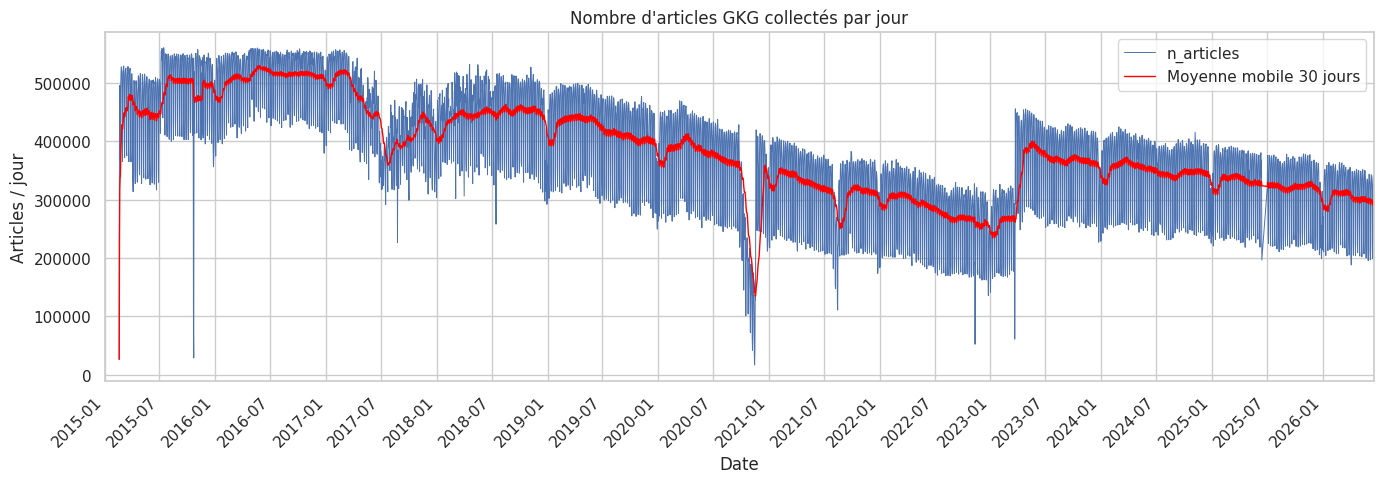

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax, linewidth=1, color="red", label="Moyenne mobile 30 jours"
)

ax.set_title("Nombre d'articles GKG collectés par jour")
ax.set_ylabel("Articles / jour")
ax.set_xlabel("Date")

ax.set_xlim(pd.to_datetime('2015-01-01'), articles_per_day.index.max())

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

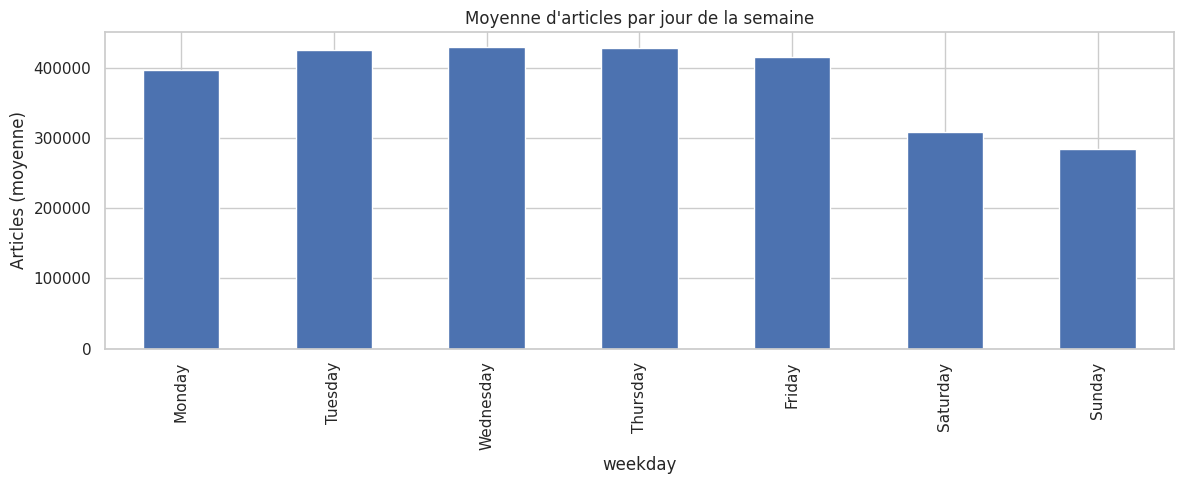

In [21]:
weekday_avg = (
    articles_per_day.assign(weekday=articles_per_day.index.day_name())
    .groupby("weekday")["n_articles"].mean()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

weekday_avg.plot(kind="bar")
plt.title("Moyenne d'articles par jour de la semaine")
plt.ylabel("Articles (moyenne)")
plt.tight_layout()
plt.show()


Calcul de l'ACF et PACF (100% Numpy/Pandas, sans statsmodels)...


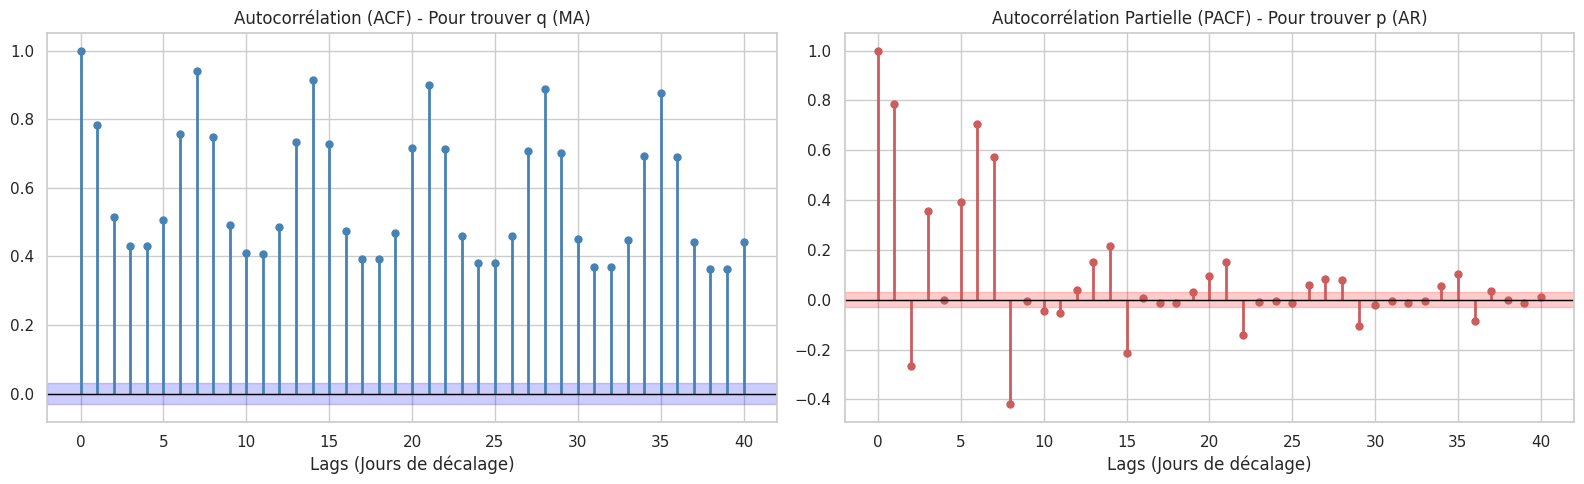

In [ ]:
# 1. Préparation de la série (On comble les trous)
ts_data = articles_per_day["n_articles"].asfreq('D').ffill()
y = ts_data.values
n = len(y)
max_lag = 40

# --- CALCUL DE L'ACF ---
acf_vals = [1.0]
y_mean = np.mean(y)
y_var = np.sum((y - y_mean)**2)

for k in range(1, max_lag + 1):
    cov = np.sum((y[k:] - y_mean) * (y[:-k] - y_mean))
    acf_vals.append(cov / y_var)

# --- CALCUL DE LA PACF (via Moindres Carrés / OLS) ---
pacf_vals = [1.0]

for k in range(1, max_lag + 1):
    # Pour le lag k, on crée une matrice de retards
    X = np.zeros((n - k, k))
    for j in range(k):
        X[:, j] = y[k - 1 - j : n - 1 - j]
        
    # On ajoute une constante à la matrice
    X = np.column_stack([np.ones(n - k), X])
    Y_target = y[k:]

    # Résolution de l'équation linéaire (X * beta = Y) avec numpy
    beta, _, _, _ = np.linalg.lstsq(X, Y_target, rcond=None)
    
    # La PACF correspond au tout dernier coefficient de la régression (le lag k)
    pacf_vals.append(beta[-1])

# --- AFFICHAGE GRAPHIQUE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
lags = np.arange(max_lag + 1)
conf_interval = 1.96 / np.sqrt(n) # Ligne bleue de significativité (95%)

# Plot ACF
axes[0].vlines(lags, [0], acf_vals, color="steelblue", linewidth=2)
axes[0].plot(lags, acf_vals, marker='o', markersize=5, color="steelblue", linestyle='None')
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhspan(-conf_interval, conf_interval, alpha=0.2, color="blue")
axes[0].set_title("Autocorrélation (ACF) - Pour trouver q (MA)")
axes[0].set_xlabel("Lags (Jours de décalage)")

# Plot PACF
axes[1].vlines(lags, [0], pacf_vals, color="indianred", linewidth=2)
axes[1].plot(lags, pacf_vals, marker='o', markersize=5, color="indianred", linestyle='None')
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhspan(-conf_interval, conf_interval, alpha=0.2, color="red")
axes[1].set_title("Autocorrélation Partielle (PACF) - Pour trouver p (AR)")
axes[1].set_xlabel("Lags (Jours de décalage)")

plt.tight_layout()
plt.show()

1. ACF Plot (Autocorrelation Function)

The ACF values decrease very slowly and stay well above the blue confidence interval for many lags --> sign of a non-stationary time series. Tere are recurring peaks exactly every 7 days (at lags 7, 14, 21, 28, and 35). This confirms a very strong weekly seasonality in the volume of published articles.

2. PACF Plot (Partial Autocorrelation Function)

There are significant spikes at the very beginning (especially lags 1 and 2) that fall outside the red confidence band : the amoubt of articles published today is heavily influenced by the previous 1 or 2 days. There is a highly significant positive spike exactly at lag 7. This aligns with the ACF findings and confirms that the previous week's volume on the same day is a strong predictor for today's volume.

## 6. Tone analysis

Calcul du Tone sur 1% de la base (Méthode Hash % 100)...


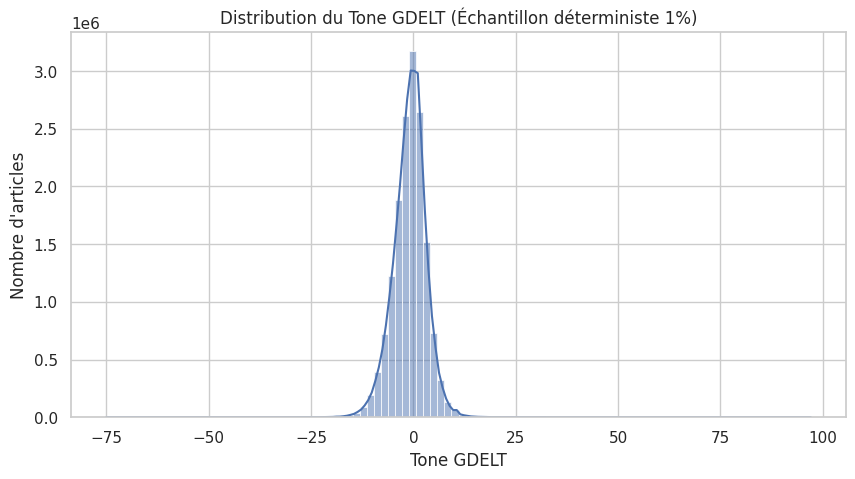

,count,mean,std,min,25%,50%,75%,max
Tone,"15,800,264.00",-0.89,3.98,-75.00,-3.23,-0.61,1.59,97.06


In [3]:
print("Calcul du Tone sur 1% de la base (Méthode Hash % 100)...")

tone_full = con.execute("""
    SELECT Tone 
    FROM gkg_clean 
    WHERE hash(GKGRECORDID) % 100 = 0
""").df()

# Visualisation
plt.figure(figsize=(10, 5))
sns.histplot(tone_full["Tone"], bins=100, kde=True)
plt.title("Distribution du Tone GDELT (Échantillon déterministe 1%)")
plt.xlabel("Tone GDELT")
plt.ylabel("Nombre d'articles")
plt.show()

# Statistiques descriptives
display(tone_full["Tone"].describe().to_frame().T)

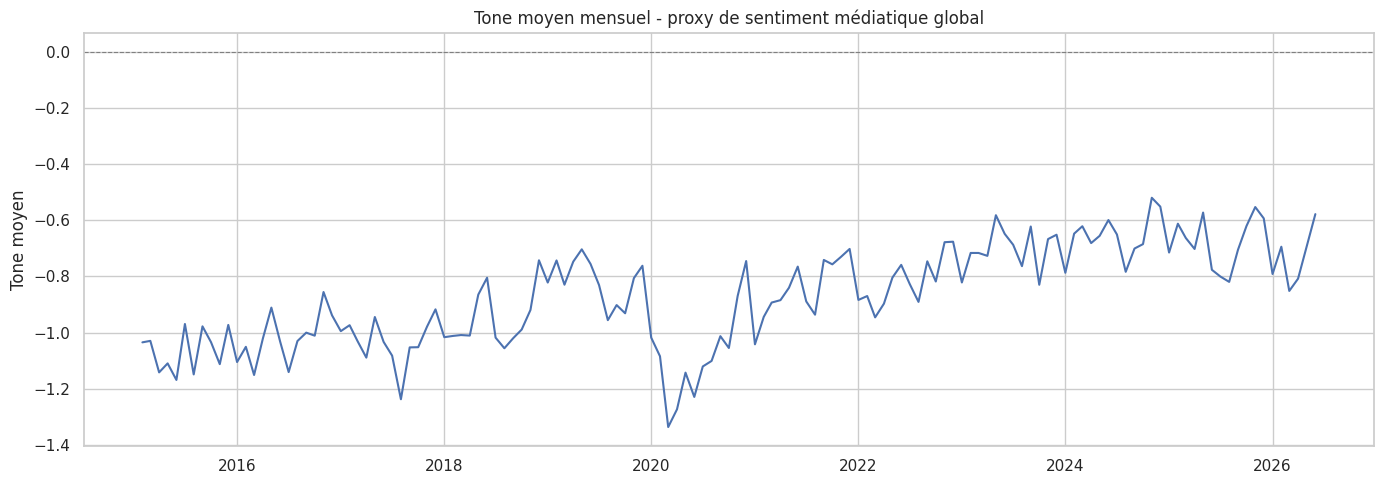

In [9]:
tone_monthly = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_clean
    GROUP BY month
    ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tone_monthly["month"], tone_monthly["avg_tone"])
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Tone moyen mensuel - proxy de sentiment médiatique global")
ax.set_ylabel("Tone moyen")
plt.tight_layout()
plt.show()


## 7. Themes analysis 

⏳ Extraction des thèmes les plus récurrents (Échantillon 10%)...


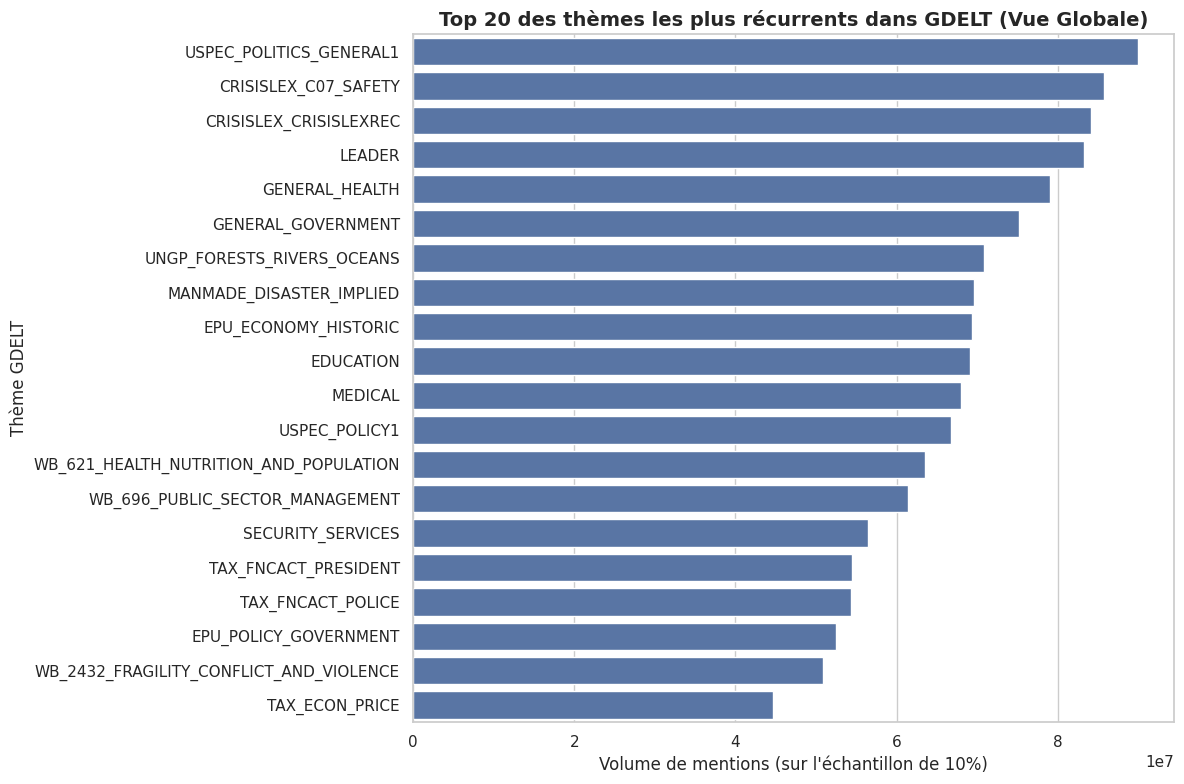

In [17]:
print("⏳ Extraction des thèmes les plus récurrents (Échantillon 10%)...")

# Extraction propre avec sous-requête pour le UNNEST
df_hist = con.execute("""
    WITH exploded AS (
        SELECT split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_clean
            WHERE hash(GKGRECORDID) % 10 = 0
        )
        WHERE theme_raw IS NOT NULL AND theme_raw != ''
    )
    SELECT theme, COUNT(*) as occurrences
    FROM exploded
    GROUP BY theme
    ORDER BY occurrences DESC
    LIMIT 20
""").df()

plt.figure(figsize=(12, 8))
sns.barplot(data=df_hist, x="occurrences", y="theme")

plt.title("Top 20 des thèmes les plus récurrents dans GDELT (Vue Globale)", fontsize=14, fontweight='bold')
plt.xlabel("Volume de mentions (sur l'échantillon de 10%)")
plt.ylabel("Thème GDELT")
plt.tight_layout()
plt.show()

In [ ]:
!pip install plotly --quiet
!pip install --upgrade nbformat
import plotly.express as px

print("Calcul de l'évolution temporelle (Version Exacte avec dédoublonnage)...")

df_time_series = con.execute("""
    -- 1. On isole d'abord notre échantillon de 2% pour ne pas saturer la RAM
    WITH base_sample AS (
        SELECT 
            GKGRECORDID,
            SUBSTRING(CAST(DATE AS VARCHAR), 1, 4) || '-' || SUBSTRING(CAST(DATE AS VARCHAR), 5, 2) AS mois,
            EnhancedThemes
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 50 = 0
    ),
    -- 2. On compte le vrai total d'articles par mois sur cet échantillon
    monthly_totals AS (
        SELECT mois, COUNT(GKGRECORDID) as total_articles
        FROM base_sample
        GROUP BY mois
    ),
    -- 3. LE CORRECTIF EST ICI : On éclate ET on dédoublonne par article (DISTINCT)
    article_themes AS (
        SELECT DISTINCT 
            GKGRECORDID, 
            mois, 
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT GKGRECORDID, mois, UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM base_sample
        )
        WHERE theme_raw IS NOT NULL AND theme_raw != ''
    ),
    -- 4. On trouve les 20 plus gros thèmes (un article = 1 vote max pour un thème)
    top_20_themes AS (
        SELECT theme, COUNT(GKGRECORDID) as total
        FROM article_themes
        GROUP BY theme
        ORDER BY total DESC
        LIMIT 20
    ),
    -- 5. On compte combien d'articles mentionnent chaque thème par mois
    theme_monthly_counts AS (
        SELECT mois, theme, COUNT(GKGRECORDID) as theme_articles
        FROM article_themes
        WHERE theme IN (SELECT theme FROM top_20_themes)
        GROUP BY mois, theme
    )
    -- 6. Calcul final du pourcentage pur
    SELECT 
        t.mois, 
        t.theme, 
        ROUND((t.theme_articles * 100.0) / m.total_articles, 2) AS pct_articles
    FROM theme_monthly_counts t
    JOIN monthly_totals m ON t.mois = m.mois
    WHERE length(t.mois) = 7
    ORDER BY t.mois ASC, t.theme ASC
""").df()

# Si tu as choisi l'affichage Web statique car Plotly plantait dans Jupyter :
fig = px.line(
    df_time_series, 
    x="mois", 
    y="pct_articles", 
    color="theme",
    title="Évolution de la part médiatique des Top 20 Thèmes mondiaux (Échantillon 2%)",
    labels={"mois": "Mois", "pct_articles": "% d'articles mentionnant le thème", "theme": "Thèmes GDELT"},
    render_mode="svg" # <-- Garde cette ligne si tu avais l'erreur WebGL
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Pourcentage d'articles réels (%)",
    hovermode="x unified", 
    legend_title="Thèmes",
    height=700
)

fig.show()

Calcul de l'évolution temporelle (Version Exacte avec dédoublonnage)...


main themes are quite stable and on't appear to have a trend over time 

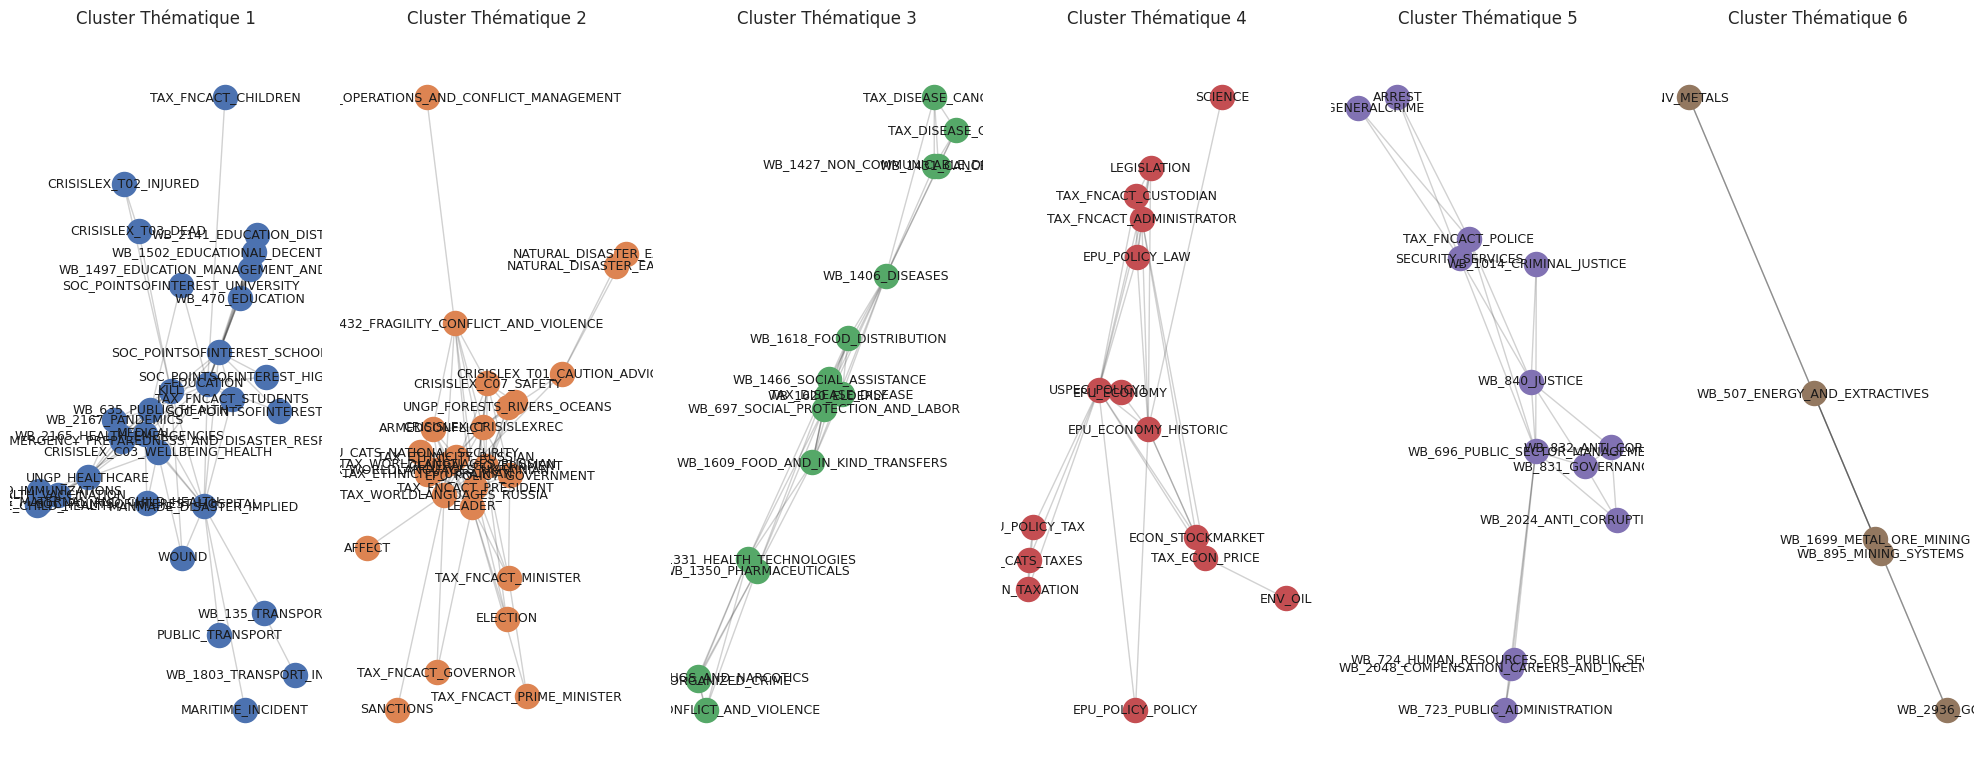

In [16]:
from networkx.algorithms import community

# 1. Utilisation de l'algorithme de Louvain (ou Greedy Modularity) pour trouver les groupes
communities = list(community.greedy_modularity_communities(G_filtered))

# 2. On ne garde que les 3 plus grosses communautés pour ne pas surcharger
num_clusters = min(len(communities), 6)
fig, axes = plt.subplots(1, num_clusters, figsize=(20, 8))

for i in range(num_clusters):
    cluster_nodes = list(communities[i])
    subgraph = G_filtered.subgraph(cluster_nodes)
    
    pos = nx.spring_layout(subgraph, k=1.5, iterations=50)
    nx.draw_networkx_nodes(subgraph, pos, ax=axes[i], node_size=300, node_color=f"C{i}")
    nx.draw_networkx_labels(subgraph, pos, ax=axes[i], font_size=9)
    nx.draw_networkx_edges(subgraph, pos, ax=axes[i], alpha=0.2)
    
    axes[i].set_title(f"Cluster Thématique {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

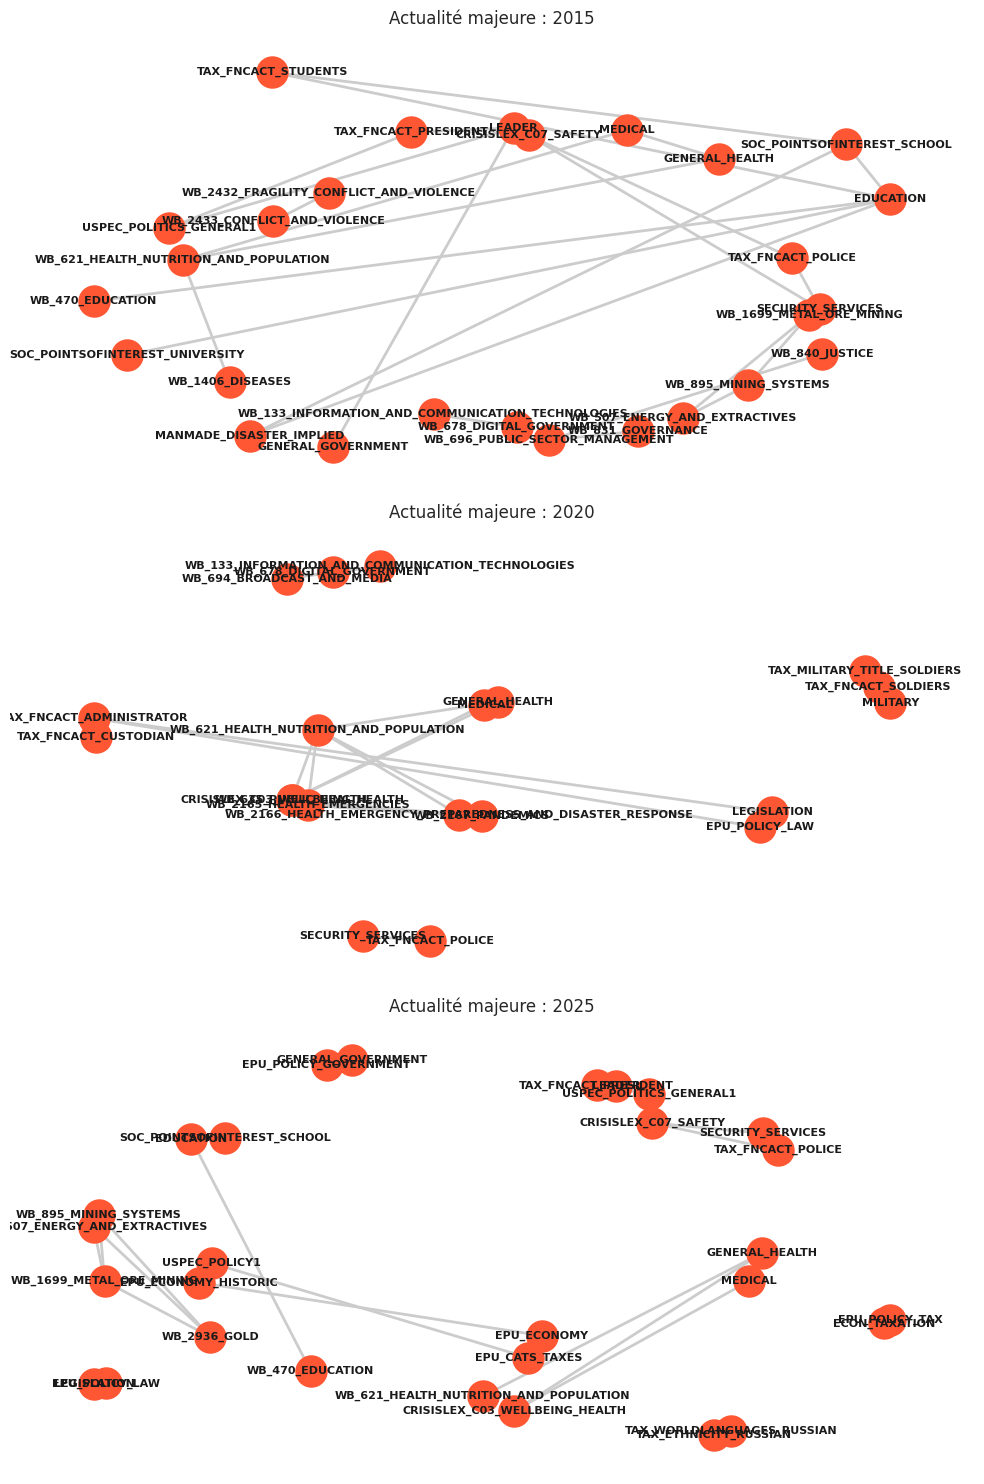

In [14]:
# Liste des années à traiter
annees = [2015, 2020,2025]

# Configuration de la grille
fig, axes = plt.subplots(len(annees), 1, figsize=(10, 5 * len(annees)))

for i, annee in enumerate(annees):
    ax = axes[i]
    
    # 1. Extraction rapide des co-occurrences (1% échantillon)
    df_pairs = con.execute(f"""
        SELECT theme1, theme2, COUNT(*) as weight
        FROM (
            SELECT split_part(t1.raw_theme, ',', 1) AS theme1, split_part(t2.raw_theme, ',', 1) AS theme2
            FROM (
                SELECT GKGRECORDID, TRIM(UNNEST(string_split(EnhancedThemes, ';'))) AS raw_theme
                FROM gkg_clean WHERE hash(GKGRECORDID) % 50 = 0 AND DATE LIKE '{annee}%'
                AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
            ) t1
            JOIN (
                SELECT GKGRECORDID, TRIM(UNNEST(string_split(EnhancedThemes, ';'))) AS raw_theme
                FROM gkg_clean WHERE hash(GKGRECORDID) % 50 = 0 AND DATE LIKE '{annee}%'
                AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
            ) t2 ON t1.GKGRECORDID = t2.GKGRECORDID
            WHERE split_part(t1.raw_theme, ',', 1) < split_part(t2.raw_theme, ',', 1)
        )
        GROUP BY theme1, theme2
        HAVING weight > 500
        ORDER BY weight DESC
        LIMIT 25
    """).df()
    
    if df_pairs.empty:
        ax.text(0.5, 0.5, 'Données manquantes', ha='center')
        continue

    # 2. Construction du graphe simplifié
    G = nx.Graph()
    for _, row in df_pairs.iterrows():
        G.add_edge(row['theme1'], row['theme2'], weight=row['weight'])
    
    # 3. Dessin épuré
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=500, node_color="#FF5733")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color="#cccccc")
    
    ax.set_title(f"Actualité majeure : {annee}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Sources

In [5]:
print("Calcul du tableau de distribution des sources...")

df_summary = con.execute("""
    WITH source_counts AS (
        SELECT SourceCommonName_ID, COUNT(*) as nb_articles
        FROM gkg_clean
        GROUP BY SourceCommonName_ID
    ),
    categorized_sources AS (
        SELECT 
            CASE 
                WHEN nb_articles = 1 THEN '1 article'
                WHEN nb_articles BETWEEN 2 AND 10 THEN '2-10 articles'
                WHEN nb_articles BETWEEN 11 AND 100 THEN '11-100 articles'
                WHEN nb_articles BETWEEN 101 AND 1000 THEN '101-1000 articles'
                ELSE '> 1000 articles'
            END AS categorie,
            nb_articles
        FROM source_counts
    )
    SELECT 
        categorie AS "Catégorie",
        COUNT(*) AS "Nombre de sources",
        SUM(nb_articles) AS "Nombre total d'articles",
        ROUND(SUM(nb_articles) * 100.0 / (SELECT COUNT(*) FROM gkg_clean), 2) AS "% du volume total"
    FROM categorized_sources
    GROUP BY categorie
    ORDER BY MIN(nb_articles) ASC
""").df()

# Affichage du tableau
from IPython.display import display
display(df_summary)

Calcul du tableau de distribution des sources...


,Catégorie,Nombre de sources,Nombre total d'articles,% du volume total
0,1 article,113108,"113,108.00",0.01
1,2-10 articles,86783,"348,580.00",0.02
2,11-100 articles,45619,"1,602,583.00",0.10
3,101-1000 articles,22359,"7,717,308.00",0.49
4,> 1000 articles,32368,"1,571,099,283.00",99.38


In [11]:
print("Calcul de la longevité avec échantillon aléatoire de sources...")

df_longevity = con.execute("""
    WITH source_stats AS (
        -- 1. On compte les années et les articles (avec JOIN pour avoir le vrai nom de la source)
        SELECT 
            g.SourceCommonName_ID, 
            m.SourceCommonName,
            COUNT(DISTINCT SUBSTRING(g.DATE, 1, 4)) AS years_active,
            COUNT(g.GKGRECORDID) AS total_articles
        FROM gkg_clean g
        LEFT JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        GROUP BY g.SourceCommonName_ID, m.SourceCommonName
    ),
    categorized_sources AS (
        -- 2. On attribue la catégorie de longévité
        SELECT 
            SourceCommonName,
            CASE 
                WHEN years_active = 1 THEN '1 an'
                WHEN years_active = 2 THEN '2 ans'
                WHEN years_active = 3 THEN '3 ans'
                WHEN years_active BETWEEN 4 AND 6 THEN '4-6 ans'
                WHEN years_active BETWEEN 7 AND 9 THEN '7-9 ans'
                WHEN years_active BETWEEN 10 AND 12 THEN '10-12 ans'
            END AS categorie,
            years_active,
            total_articles
        FROM source_stats
    ),
    ranked_sources AS (
        -- 3. On tire au sort un classement aléatoire pour chaque source au sein de sa catégorie
        SELECT 
            categorie,
            SourceCommonName,
            ROW_NUMBER() OVER (PARTITION BY categorie ORDER BY random()) as random_rank
        FROM categorized_sources
        WHERE SourceCommonName IS NOT NULL
    ),
    samples AS (
        -- 4. On garde les 10 premiers du tirage au sort et on les fusionne en texte
        SELECT 
            categorie,
            string_agg(SourceCommonName, ', ') AS sample_text
        FROM ranked_sources
        WHERE random_rank <= 10
        GROUP BY categorie
    ),
    stats AS (
        -- 5. On calcule les statistiques globales
        SELECT 
            categorie,
            COUNT(*) AS "Nombre de sources",
            SUM(total_articles) AS "Nombre total d'articles", 
            ROUND(SUM(total_articles) * 100.0 / (SELECT COUNT(*) FROM gkg_clean), 2) AS "% du volume total",
            MIN(years_active) AS sort_order -- Astuce pour trier correctement sans avoir à le faire en Python
        FROM categorized_sources
        GROUP BY categorie
    )
    -- 6. On assemble les statistiques et l'échantillon
    SELECT 
        st.categorie AS "Longevité",
        st."Nombre de sources",
        st."Nombre total d'articles", 
        st."% du volume total",
        sa.sample_text AS "Échantillon (10 sources au hasard)"
    FROM stats st
    JOIN samples sa ON st.categorie = sa.categorie
    ORDER BY st.sort_order ASC
""").df()

pd.set_option('display.max_colwidth', None)

display(df_longevity)

Calcul de la longevité avec échantillon aléatoire de sources...


,Longevité,Nombre de sources,Nombre total d'articles,% du volume total,Échantillon (10 sources au hasard)
0,1 an,164664,"4,240,212.00",0.27,"shsarmet.cz, driversupport.com, charico2019.blog.jp, australianbluegrass.com, gen.com.sg, tin365.info, atheistnexus.org, mellowed.nl, rentonwa.gov, paulcornell.com"
1,2 ans,50568,"15,233,804.00",0.96,"galletti.com, voxcatch.fr, pettengillmissionaries.org, hlntv.com, thethoughtfulcoalminer.com, hexacta.com, rescueapitbull.com, jcrew.com, anime-now.com, market.cnews.ru"
2,3 ans,19972,"18,794,456.00",1.19,"techstuffer.com, newdaypost.com, fansshare.com, livewallpapers.com, motofilm.pl, stableytimes.com, crrh.org, consultancy.eu, wagjag.com, wroclaw.wp.pl"
3,4-6 ans,31119,"89,410,276.00",5.66,"focus-numerique.com, workawayblog.com, duffelblog.com, tamahereforum.co.nz, thatskinnychickcanbake.com, infocomma.net, cricnepal.com, louisville.com, theworldbeast.com, nextjs.org"
4,7-9 ans,15294,"229,909,490.00",14.54,"thatballsouttahere.com, syngenta.com, thegroundtruthproject.org, foodanddrinkbusiness.com.au, xedoisong.vn, dnes.bg, toronews.net, elwaha-dz.com, olympic.cn, northfloridanow.com"
5,10-12 ans,18620,"1,223,292,624.00",77.38,"tovima.gr, ohridnews.com, cornwallseawaynews.com, star883.com, rentonreporter.com, theperspective.org, onb.ac.at, oeildafrique.com, vikalpa.org, gazeteciler.com"


lots of noisy websites : github.io pages, personnal websites, religious, tourisme, e commerce, organizations official websites, social networks...
a few examples : 

*     "145552": "nickdesaulniers.github.io",
*     "lordoftheringstours.co.nz": 215895,
*     "uniqlo.com": 69537,
*     "letjesushelpyou.com": 109488,
*     "ubisoft.com": 232123,
*     "118866": "fromsoftware.jp",
*     "280397": "olympics.com",
*     "86358": "chess.com",


In [9]:
import pandas as pd

# On force l'affichage complet pour ne pas couper les URLs
pd.set_option('display.max_colwidth', None)

print("Récupération d'un article au hasard pour les sources atypiques...")

df_samples = con.execute("""
    WITH target_sources AS (
        -- On crée une liste avec les noms de tes sources
        SELECT unnest([
            'nickdesaulniers.github.io',
            'lordoftheringstours.co.nz',
            'uniqlo.com',
            'letjesushelpyou.com',
            'ubisoft.com',
            'fromsoftware.jp',
            'olympics.com', 'chess.com'
        ]) AS source_name
    ),
    ranked_articles AS (
        SELECT 
            m.SourceCommonName,
            SUBSTRING(CAST(g.DATE AS VARCHAR), 1, 8) as Date_Publication, -- Format AAAAMMJJ
            g.DocumentIdentifier AS URL_Article,
            g.Tone,
            g.EnhancedThemes, g.EnhancedLocations, g.Persons, g.Organizations,
            ROW_NUMBER() OVER (PARTITION BY m.SourceCommonName ORDER BY random()) as rn
        FROM gkg_clean g
        JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        JOIN target_sources ts ON m.SourceCommonName = ts.source_name
    )
    SELECT 
        SourceCommonName AS "Source", 
        Date_Publication AS "Date", 
        URL_Article AS "Lien de l'article",
        Tone AS "Tone", 
        EnhancedThemes AS "Thèmes",
        EnhancedLocations AS "Lieux",
        Persons AS "Personnes",
        Organizations AS "Organisations"
    FROM ranked_articles
    WHERE rn = 1
""").df()

display(df_samples)

Récupération d'un article au hasard pour les sources atypiques...


,Source,Date,Lien de l'article,Tone,Thèmes,Lieux,Personnes,Organisations
0,nickdesaulniers.github.io,20160121,http://nickdesaulniers.github.io/blog/2016/01/20/debugging-x86-64-assembly-with-lldb-and-dtrace/,0.60,"TAX_FOODSTAPLES_BREAD,545;CYBER_ATTACK,12;",,,
1,fromsoftware.jp,20150913,http://www.fromsoftware.jp/pc_en/news/pressrelease/20150912_fukuokastudio_pressrelease.html,3.42,,"4#Tokyo, Tokyo, Japan#JA#JA40#36340#35.685#139.751#-246227#6;4#Tokyo, Tokyo, Japan#JA#JA40#36340#35.685#139.751#-246227#472;4#Tokyo, Tokyo, Japan#JA#JA40#36340#35.685#139.751#-246227#548;4#Fukuoka, Fukuoka, Japan#JA#JA07#33728#33.5833#130.4#-227372#90;4#Fukuoka, Fukuoka, Japan#JA#JA07#33728#33.5833#130.4#-227372#356;4#Fukuoka, Fukuoka, Japan#JA#JA07#33728#33.5833#130.4#-227372#488;4#Fukuoka, Fukuoka, Japan#JA#JA07#33728#33.5833#130.4#-227372#1001;4#Fukuoka, Fukuoka, Japan#JA#JA07#33728#33.5833#130.4#-227372#1113;4#Fukuoka, Fukuoka, Japan#JA#JA07#33728#33.5833#130.4#-227372#1204;1#Japan#JA#JA##36#138#JA#13;1#Japan#JA#JA##36#138#JA#97;1#Japan#JA#JA##36#138#JA#105;1#Japan#JA#JA##36#138#JA#363;1#Japan#JA#JA##36#138#JA#479;1#Japan#JA#JA##36#138#JA#495;1#Japan#JA#JA##36#138#JA#555;1#Japan#JA#JA##36#138#JA#1008;1#Japan#JA#JA##36#138#JA#1120;1#Japan#JA#JA##36#138#JA#1211;1#Japan#JA#JA##36#138#JA#1224;1#Japan#JA#JA##36#138#JA#1296;1#Japan#JA#JA##36#138#JA#1351;4#Hakozaki, Fukuoka, Japan#JA#JA07#33729#33.6167#130.417#-228245#1289;4#Hakozaki, Fukuoka, Japan#JA#JA07#33729#33.6167#130.417#-228245#1344",narayamachi hakata-ku,fromsoftware inc
2,letjesushelpyou.com,20160206,http://letjesushelpyou.com/2016/02/lost-in-my-hometown/,-2.49,"SOC_POINTSOFINTEREST_HOSPITAL,1001;SOC_POINTSOFINTEREST_HOSPITAL,1197;SOC_POINTSOFINTEREST_HOSPITAL,1626;CRISISLEX_C03_WELLBEING_HEALTH,1001;CRISISLEX_C03_WELLBEING_HEALTH,1197;CRISISLEX_C03_WELLBEING_HEALTH,1626;GENERAL_HEALTH,699;MEDICAL,699;TAX_FNCACT_VOLUNTEER,358;WB_168_ROADS_AND_HIGHWAYS,808;WB_135_TRANSPORT,808;WB_1809_HIGHWAYS,808;WB_1803_TRANSPORT_INFRASTRUCTURE,808;WB_1160_SHOCKS_AND_VULNERABILITY,882;WB_695_POVERTY,882;CRISISLEX_O01_WEATHER,266;",1#India#IN#IN##20#77#IN#313;1#Italy#IT#IT##42.8333#12.8333#IT#493;1#Nepal#NP#NP##28#84#NP#321,,
3,ubisoft.com,20191029,https://ghost-recon.ubisoft.com/game/en-gb/news-updates/6Bb2b4t42qC0ar5B3t5rmM/tom-clancys-ghost-recon-breakpoint-moving-forward,0.35,,,,ghost recon team;mission completion;delta company
4,uniqlo.com,20191101,https://www.uniqlo.com/us/en/employment/about.html,2.64,"URBAN,238;TAX_ECON_PRICE,673;EPU_ECONOMY_HISTORIC,1346;TAX_FNCACT_RETAILER,503;WB_471_ECONOMIC_GROWTH,820;WB_1078_DETERMINANTS_OF_GROWTH,820;WB_290_TELECOMMUNICATIONS_ORGANIZATIONAL_DESIGN,1352;WB_288_TELECOMMUNICATIONS_SECTOR_POLICY_AND_REGULATION,1352;WB_286_TELECOMMUNICATIONS_AND_BROADBAND_ACCESS,1352;WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOGIES,1352;WB_1921_PRIVATE_SECTOR_DEVELOPMENT,604;WB_346_COMPETITIVE_INDUSTRIES,604;WB_818_INDUSTRY_POLICY_AND_REAL_SECTORS,604;WB_1281_MANUFACTURING,604;TAX_ETHNICITY_JAPANESE,753;TAX_WORLDLANGUAGES_JAPANESE,753;TAX_FNCACT_DRIVERS,810;","1#United Kingdom#UK#UK##54#-4#UK#888;1#Taiwan#TW#TW##24#121#TW#1059;4#Shinjuku, Kanagawa, Japan#JA#JA19#34812#35.3167#139.35#-229376#446;1#South Korea#KS#KS##37#127.5#KS#1073;1#Japanese#JA#JA##36#138#JA#753;4#Osaka, Osaka, Japan#JA#JA32#35840#34.6667#135.5#-240905#461;1#Japan#JA#JA##36#138#JA#145;1#Japan#JA#JA##36#138#JA#312;1#Japan#JA#JA##36#138#JA#435;1#Japan#JA#JA##36#138#JA#453;1#Japan#JA#JA##36#138#JA#468;1#Japan#JA#JA##36#138#JA#1030;1#Japan#JA#JA##36#138#JA#1211;4#Ginza, Tokyo, Japan#JA#JA40#36344#35.6667#139.767#-227868#428;1#Hong Kong#HK#HK##22.25#114.166667#HK#1050;1#China#CH#CH##35#105#CH#1038",,
5,olympics.com,20250806,https://www.olympics.com/en/news/mijain-lopez-interview-fifth-olympic-gold-life-after-wrestling,1.66,,"4#Paris, France (General), France#FR#FR00#16282#48.8667#2.33333#-1456928#53;4#Paris, France (General), France#FR#FR00#16282#48.8667#2.33333#-1456928#994;1#French#FR#FR##46#2#FR#220;1#Cuba#CU#CU##2

many of these sources have articles with Themes and other metadata, motivating a prior cleansing of the dataframe. 